Dataset Shape: (1000, 8)

Missing Values:
Airline           0
Origin            0
Destination       0
Departure_Hour    0
Distance          0
Weather           0
Previous_Delay    0
Delayed           0
dtype: int64

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Airline         1000 non-null   int32
 1   Origin          1000 non-null   int32
 2   Destination     1000 non-null   int32
 3   Departure_Hour  1000 non-null   int32
 4   Distance        1000 non-null   int32
 5   Weather         1000 non-null   int32
 6   Previous_Delay  1000 non-null   int32
 7   Delayed         1000 non-null   int64
dtypes: int32(7), int64(1)
memory usage: 35.3 KB
None


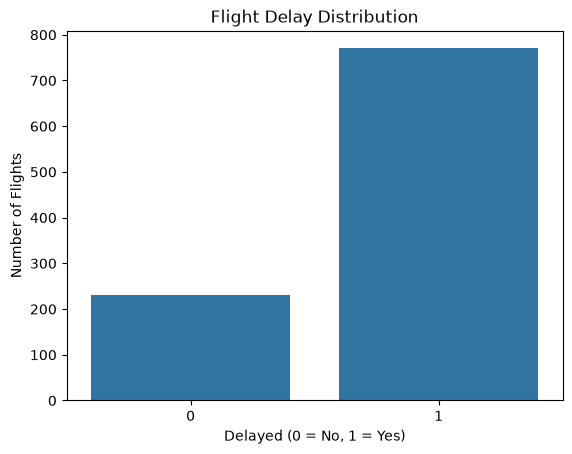

Training Data: (800, 7)
Testing Data: (200, 7)
XGBoost model trained successfully!
Accuracy: 1.0
Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00       150

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



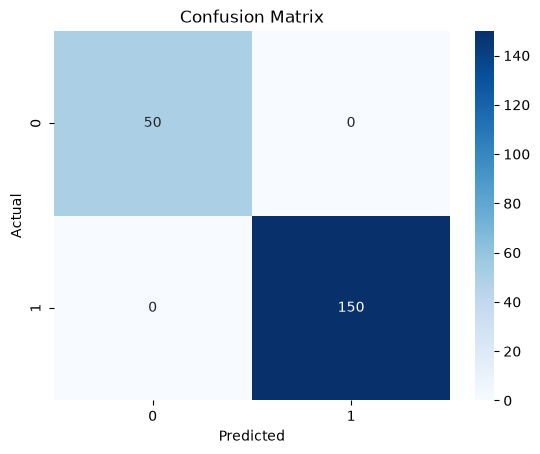

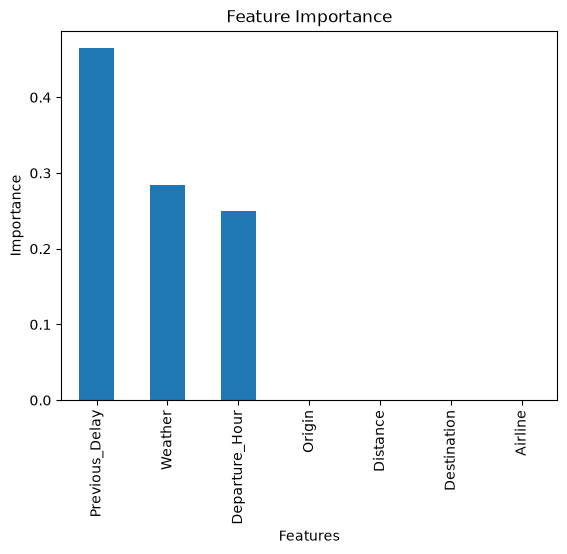

✈️ Flight is likely to be DELAYED
 Flight Delay Prediction using XGBoost
Model Accuracy: 100.0 %


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
np.random.seed(42)

data = {
    "Airline": np.random.randint(0, 5, 1000),
    "Origin": np.random.randint(0, 10, 1000),
    "Destination": np.random.randint(0, 10, 1000),
    "Departure_Hour": np.random.randint(0, 24, 1000),
    "Distance": np.random.randint(200, 3000, 1000),
    "Weather": np.random.randint(0, 3, 1000),
    "Previous_Delay": np.random.randint(0, 2, 1000)
}

df = pd.DataFrame(data)

# Create target variable
df["Delayed"] = (
    (df["Departure_Hour"] >= 17) |
    (df["Weather"] == 2) |
    (df["Previous_Delay"] == 1)
).astype(int)

df.head()
print("Dataset Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())

print("\nDataset Information:")
print(df.info())
sns.countplot(x="Delayed", data=df)
plt.title("Flight Delay Distribution")
plt.xlabel("Delayed (0 = No, 1 = Yes)")
plt.ylabel("Number of Flights")
plt.show()
X = df.drop("Delayed", axis=1)
y = df["Delayed"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)
model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

model.fit(X_train, y_train)

print("XGBoost model trained successfully!")
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Classification Report:\n")
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance.plot(kind="bar")
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()
new_flight = pd.DataFrame({
    "Airline": [2],
    "Origin": [3],
    "Destination": [7],
    "Departure_Hour": [19],
    "Distance": [1200],
    "Weather": [2],
    "Previous_Delay": [1]
})

prediction = model.predict(new_flight)

if prediction[0] == 1:
    print("✈️ Flight is likely to be DELAYED")
else:
    print("✈️ Flight is likely to be ON TIME")
    print("===================================")
print(" Flight Delay Prediction using XGBoost")
print("===================================")
print("Model Accuracy:", round(accuracy * 100, 2), "%")